In [1]:
from dmri.simulators.local_signal_models.sphereical_distributions import SD1Watson, hemisphere, sphere
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt


/root/simformer_model_selection/dmri/dmri/simulators/local_signal_models/sphereical_distributions.py:14: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere("symmetric724")


In [41]:
dist = SD1Watson(jnp.array([1.0,0.0]), 0.01)

In [42]:
pdfs = dist.pdf(sphere.vertices)

In [43]:
samples = dist.sample(jax.random.key(1), (1000,))

In [44]:
samples.shape

(1000, 3)

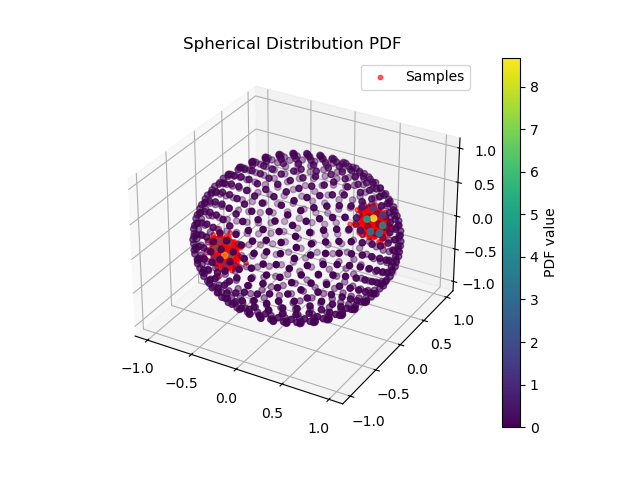

In [45]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# plot sphere vertices colored by their pdf
sc = ax.scatter(sphere.vertices[:, 0],
                sphere.vertices[:, 1],
                sphere.vertices[:, 2],
                c=pdfs, cmap='viridis')
# overlay sample points in red
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
           color='red', s=10, alpha=0.6, label='Samples')
plt.colorbar(sc, label='PDF value')
ax.set_title('Spherical Distribution PDF')
ax.legend()
plt.show()

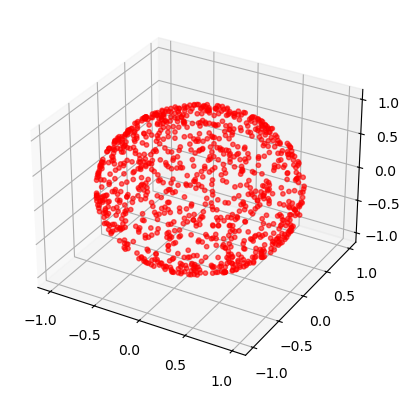

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# plot sphere vertices colored by their pdf

# overlay sample points in red
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
           color='red', s=10, alpha=0.6, label='Samples')

In [9]:

def sample_watson_ar_1(key, mu, kappa):
    """
    Draw a single sample from Watson(mu, kappa) on the unit sphere using
    acceptance-rejection from the uniform distribution on S^{d-1}.

    Arguments:
      key:    a jax.random.PRNGKey
      mu:     a jnp.ndarray of shape (d,) — will be normalized internally
      kappa:  a nonnegative float (concentration parameter)
    Returns:
      A jnp.ndarray of shape (d,) lying on the unit sphere, distributed ~ Watson(mu,kappa).
    """
    mu = mu / jnp.linalg.norm(mu)  # ensure mu is a unit vector

    def cond_fn(state):
        # state = (key, accepted, candidate)
        _, accepted, _ = state
        return jnp.logical_not(accepted)

    def body_fn(state):
        key, _, _ = state
        key, subkey1, subkey2 = jax.random.split(key, 3)

        # 1) Propose x ~ Uniform(S^{d-1})
        z = jax.random.normal(subkey1, shape=mu.shape)
        x_proposal = z / jnp.linalg.norm(z)

        # 2) Acceptance probability
        log_accept_ratio = kappa * ((mu @ x_proposal) ** 2 - 1.0)
        u = jax.random.uniform(subkey2)

        accepted = jnp.log(u) <= log_accept_ratio
        return (key, accepted, x_proposal)

    # Initialize and run the while loop
    init_state = (key, False, jnp.zeros_like(mu))
    final_state = jax.lax.while_loop(cond_fn, body_fn, init_state)
    _, _, x_accepted = final_state

    return x_accepted

In [10]:
sample_watson_ar_1(jax.random.PRNGKey(1), jnp.array([1., 0.]), 1.0)

Array([ 0.623589  , -0.78175235], dtype=float32)